In [2]:
import os
from pathlib import Path
from PIL import Image

In [14]:
# configure paths

DATASET_ROOT = Path("dataset")

GRAY_ROOT = Path("dataset_grey")

CLASSES = ["dys","kolio","meta","para","super"]

SUBDIR = "CROPPED"

EXTENSIONS = {".bmp",".png",".jpg","jpeg"}

In [15]:
def convert_to_grayscale(src_path: Path, dst_path: Path) -> None:
    """Open an image, convert to grayscale (L mode), save to dst."""
    img = Image.open(src_path).convert("L")   # 'L' = 8-bit grayscale
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    img.save(dst_path)
 
 
def main():
    total_converted = 0
    total_skipped   = 0
 
    for cls in CLASSES:
        src_dir = DATASET_ROOT / cls / SUBDIR
        dst_dir = GRAY_ROOT    / cls / SUBDIR
 
        if not src_dir.exists():
            print(f"[WARN] Source directory not found, skipping: {src_dir}")
            continue
 
        files = sorted(src_dir.iterdir())
        count = 0
 
        for src_file in files:
            if src_file.suffix.lower() not in EXTENSIONS:
                continue
 
            dst_file = dst_dir / src_file.name
 
            if dst_file.exists():
                total_skipped += 1
                continue
 
            try:
                convert_to_grayscale(src_file, dst_file)
                count += 1
                total_converted += 1
            except Exception as e:
                print(f"  [ERROR] {src_file.name}: {e}")
 
        print(f"  [{cls}] Converted {count} images  →  {dst_dir}")
 
    print(f"\nDone!  Converted: {total_converted}  |  Skipped (already exist): {total_skipped}")
    print(f"Grayscale dataset saved to: {GRAY_ROOT.resolve()}")
 
 
if __name__ == "__main__":
    main()

  [dys] Converted 823 images  →  dataset_grey/dys/CROPPED
  [kolio] Converted 825 images  →  dataset_grey/kolio/CROPPED
  [meta] Converted 793 images  →  dataset_grey/meta/CROPPED
  [para] Converted 787 images  →  dataset_grey/para/CROPPED
  [super] Converted 831 images  →  dataset_grey/super/CROPPED

Done!  Converted: 4059  |  Skipped (already exist): 0
Grayscale dataset saved to: /home/the2003onean/Documents/deep/dataset_grey


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers,Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns

In [17]:
GRAY_ROOT = Path("dataset_grey")
CLASSES = ["dys","kolio","meta","para","super"]

IMG_SIZE = (96,96) #mobile net v2 mi is 96 X 96; unsample from 326X148

IMG_CHANNELS = 3 #it needs 3 channels

BATCH_SIZE = 25

EPOCHS = 45

VAL_SPLIT = 0.15

TEST_SPLIT = 0.15

SEED = 42

SAVE_PATH = "model.h5"

In [18]:
 
# ── 1. Collect all image paths & labels ───────────────────────────────────────
def collect_data(root: Path, classes: list):
    paths, labels = [], []
    for idx, cls in enumerate(classes):
        img_dir = root / cls / "CROPPED"
        if not img_dir.exists():
            print(f"[WARN] Missing: {img_dir}")
            continue
        imgs = list(img_dir.glob("*.bmp")) + list(img_dir.glob("*.png")) + \
               list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.jpeg"))
        paths.extend([str(p) for p in imgs])
        labels.extend([idx] * len(imgs))
        print(f"  {cls:10s}: {len(imgs):4d} images")
    return np.array(paths), np.array(labels)
 
 
print("=== Collecting images ===")
all_paths, all_labels = collect_data(GRAY_ROOT, CLASSES)
print(f"Total: {len(all_paths)} images across {len(CLASSES)} classes\n")
 

=== Collecting images ===
  dys       :  823 images
  kolio     :  825 images
  meta      :  793 images
  para      :  787 images
  super     :  831 images
Total: 4059 images across 5 classes



In [21]:
#2 train val test split
from sklearn.model_selection import train_test_split
 
X_train, X_temp, y_train, y_temp = train_test_split(
    all_paths, all_labels,
    test_size=(VAL_SPLIT + TEST_SPLIT),
    random_state=SEED, stratify=all_labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
    random_state=SEED, stratify=y_temp
)
print(f"Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")

Train: 2841  |  Val: 609  |  Test: 609


In [28]:
# ── 3. tf.data pipeline ───────────────────────────────────────────────────────
def load_and_preprocess(path, label):
    raw   = tf.io.read_file(path)
    img   = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img   = tf.image.rgb_to_grayscale(img)
    img   = tf.image.resize(img, IMG_SIZE)
    img   = tf.repeat(img, 3, axis=-1)        # grayscale → 3-channel
    img   = tf.cast(img, tf.float32) / 127.5 - 1.0  # MobileNetV2 range [-1,1]
    label = tf.cast(label, tf.int32)
    return img, label
 
 
AUTOTUNE = tf.data.AUTOTUNE
 
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, -1.0, 1.0)
    return img, label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(buffer_size=1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds
 
 
train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)

In [24]:
# ── 4. Build MobileNetV2 model ────────────────────────────────────────────────
def build_model(num_classes: int) -> Model:
    base = MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )
    # Phase 1: freeze base
    base.trainable = False
 
    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
 
    model = Model(inputs, outputs)
    return model, base
 
 
model, base_model = build_model(len(CLASSES))
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [29]:
# ── 5. Phase 1: Train head only ───────────────────────────────────────────────
callbacks = [
    ModelCheckpoint(SAVE_PATH, monitor="val_accuracy", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]
 
print("\n=== Phase 1: Training head (base frozen) ===")
history1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=min(20, EPOCHS), callbacks=callbacks, verbose=1
)
 


=== Phase 1: Training head (base frozen) ===
Epoch 1/20
113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6037 - loss: 1.0947
Epoch 1: val_accuracy improved from None to 0.79475, saving model to model.h5



Epoch 1: finished saving model to model.h5
114/114 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.6917 - loss: 0.8294 - val_accuracy: 0.7947 - val_loss: 0.5285 - learning_rate: 0.0010
Epoch 2/20
113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7873 - loss: 0.5953
Epoch 2: val_accuracy did not improve from 0.79475
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.7793 - loss: 0.5837 - val_accuracy: 0.7931 - val_loss: 0.5196 - learning_rate: 0.0010
Epoch 3/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7988 - loss: 0.5289
Epoch 3: val_accuracy improved from 0.79475 to 0.80624, saving model to model.h5



Epoch 3: finished saving model to model.h5
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.8061 - loss: 0.5074 - val_accuracy: 0.8062 - val_loss: 0.4865 - learning_rate: 0.0010
Epoch 4/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8171 - loss: 0.4766
Epoch 4: val_accuracy improved from 0.80624 to 0.81281, saving model to model.h5



Epoch 4: finished saving model to model.h5
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.8173 - loss: 0.4623 - val_accuracy: 0.8128 - val_loss: 0.4745 - learning_rate: 0.0010
Epoch 5/20
113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8306 - loss: 0.4390
Epoch 5: val_accuracy improved from 0.81281 to 0.81609, saving model to model.h5



Epoch 5: finished saving model to model.h5
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.8300 - loss: 0.4396 - val_accuracy: 0.8161 - val_loss: 0.4627 - learning_rate: 0.0010
Epoch 6/20
113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8385 - loss: 0.4033
Epoch 6: val_accuracy improved from 0.81609 to 0.83744, saving model to model.h5



Epoch 6: finished saving model to model.h5
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.8282 - loss: 0.4247 - val_accuracy: 0.8374 - val_loss: 0.4433 - learning_rate: 0.0010
Epoch 7/20
113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8604 - loss: 0.3714
Epoch 7: val_accuracy did not improve from 0.83744
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.8557 - loss: 0.3840 - val_accuracy: 0.8194 - val_loss: 0.4616 - learning_rate: 0.0010
Epoch 8/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8497 - loss: 0.4102
Epoch 8: val_accuracy did not improve from 0.83744
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.8578 - loss: 0.3866 - val_accuracy: 0.8243 - val_loss: 0.4340 - learning_rate: 0.0010
Epoch 9/20
113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8661 - loss: 0.3412
Epoch 9: val_accuracy did not improve from 0.83744
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.8666 - loss: 0.3507 - val_accuracy: 0.8374 - val_loss: 0.415


Epoch 12: finished saving model to model.h5
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.8747 - loss: 0.3246 - val_accuracy: 0.8489 - val_loss: 0.4032 - learning_rate: 0.0010
Epoch 13/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8776 - loss: 0.3160
Epoch 13: val_accuracy did not improve from 0.84893
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.8828 - loss: 0.3101 - val_accuracy: 0.8325 - val_loss: 0.3996 - learning_rate: 0.0010
Epoch 14/20
113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8931 - loss: 0.2847
Epoch 14: val_accuracy did not improve from 0.84893
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.8828 - loss: 0.2938 - val_accuracy: 0.8177 - val_loss: 0.4601 - learning_rate: 0.0010
Epoch 15/20
113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8859 - loss: 0.3093
Epoch 15: val_accuracy did not improve from 0.84893
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.8870 - loss: 0.2981 - val_accuracy: 0.8325 - val_loss


Epoch 20: finished saving model to model.h5
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.9233 - loss: 0.2118 - val_accuracy: 0.8539 - val_loss: 0.3929 - learning_rate: 5.0000e-04


In [30]:
# ── 6. Phase 2: Fine-tune top layers of MobileNetV2 ──────────────────────────
print("\n=== Phase 2: Fine-tuning top 30 layers of MobileNetV2 ===")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
 
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),   # lower LR for fine-tuning
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
 
remaining_epochs = EPOCHS - len(history1.history["loss"])
history2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=remaining_epochs, callbacks=callbacks, verbose=1
)


=== Phase 2: Fine-tuning top 30 layers of MobileNetV2 ===
Epoch 1/25
113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6777 - loss: 1.7296
Epoch 1: val_accuracy did not improve from 0.85386
114/114 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.7455 - loss: 1.1347 - val_accuracy: 0.7964 - val_loss: 0.5593 - learning_rate: 1.0000e-04
Epoch 2/25
113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8285 - loss: 0.5799
Epoch 2: val_accuracy did not improve from 0.85386
114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.8254 - loss: 0.5705 - val_accuracy: 0.7964 - val_loss: 0.5553 - learning_rate: 1.0000e-04
Epoch 3/25
113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8511 - loss: 0.4152
Epoch 3: val_accuracy did not improve from 0.85386
114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.8462 - loss: 0.4290 - val_accuracy: 0.8062 - val_loss: 0.5116 - learning_rate: 1.0000e-04
Epoch 4/25
113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8644 - loss: 0.4020

In [31]:
# ── 7. Evaluate on test set ───────────────────────────────────────────────────
print("\n=== Test Set Evaluation ===")
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%   |   Test Loss: {test_loss:.4f}")
 
y_pred = np.argmax(model.predict(test_ds), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES))


=== Test Set Evaluation ===
Test Accuracy: 79.80%   |   Test Loss: 0.6111
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step

Classification Report:
              precision    recall  f1-score   support

         dys       0.74      0.75      0.75       124
       kolio       0.82      0.66      0.73       124
        meta       0.75      0.65      0.69       119
        para       0.74      0.98      0.84       118
       super       0.95      0.95      0.95       124

    accuracy                           0.80       609
   macro avg       0.80      0.80      0.79       609
weighted avg       0.80      0.80      0.79       609



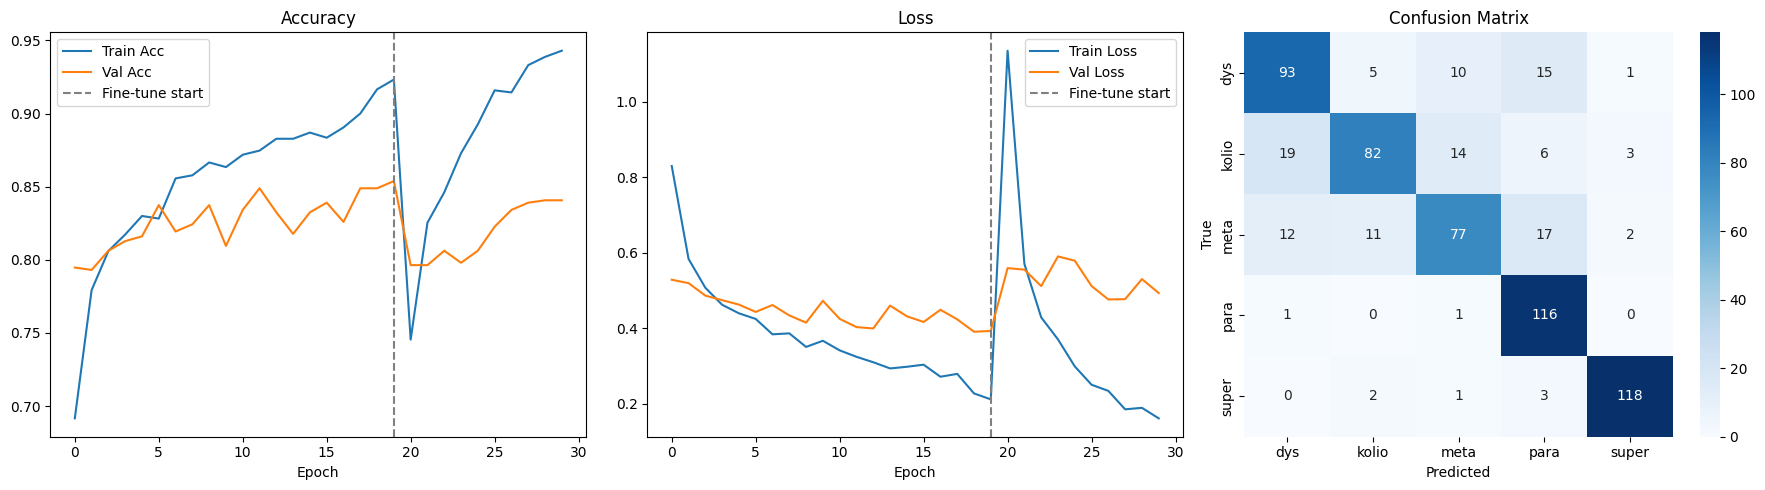


Plot saved: training_history.png
Model saved: model.h5


In [32]:
# ── 8. Plots ──────────────────────────────────────────────────────────────────
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged
 
hist = merge_histories(history1, history2)
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# Accuracy
axes[0].plot(hist["accuracy"],     label="Train Acc")
axes[0].plot(hist["val_accuracy"], label="Val Acc")
axes[0].axvline(len(history1.history["loss"])-1, color="gray", linestyle="--", label="Fine-tune start")
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].set_xlabel("Epoch")
 
# Loss
axes[1].plot(hist["loss"],     label="Train Loss")
axes[1].plot(hist["val_loss"], label="Val Loss")
axes[1].axvline(len(history1.history["loss"])-1, color="gray", linestyle="--", label="Fine-tune start")
axes[1].set_title("Loss"); axes[1].legend(); axes[1].set_xlabel("Epoch")
 
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[2])
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
 
plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()
print("\nPlot saved: training_history.png")
print(f"Model saved: {SAVE_PATH}")

In [33]:
#test


  Prediction  :  SUPER
  Confidence  :  99.91%

All class probabilities:
  dys         0.01%  
  kolio       0.00%  
  meta        0.08%  
  para        0.00%  
  super      99.91%  ███████████████████████████████████████


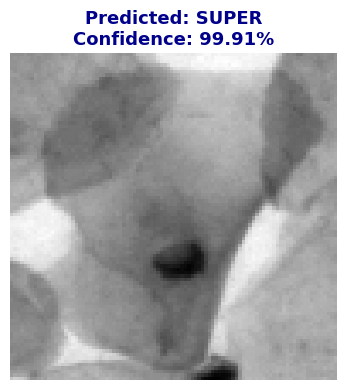


Saved: my_prediction.png


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
 
# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
MODEL_PATH = "model.h5"
CLASSES    = ["dys", "kolio", "meta", "para", "super"]
IMG_SIZE   = (96, 96)
# ─────────────────────────────────────────────
 
# ── Load model ────────────────────────────────
model = tf.keras.models.load_model(MODEL_PATH)
 
# ── Ask user for image path ───────────────────
print("=" * 50)
image_path = "/home/the2003onean/Downloads/017_20.bmp"
print("=" * 50)
 
if not Path(image_path).exists():
    print(f"ERROR: File not found → {image_path}")
    exit()
 
# ── Preprocess ────────────────────────────────
raw = tf.io.read_file(image_path)
img = tf.image.decode_image(raw, channels=3, expand_animations=False)
img = tf.image.rgb_to_grayscale(img)
img = tf.image.resize(img, IMG_SIZE)
img = tf.repeat(img, 3, axis=-1)
img = tf.cast(img, tf.float32) / 127.5 - 1.0
 
input_batch = tf.expand_dims(img, 0)
 
# ── Predict ───────────────────────────────────
preds      = model.predict(input_batch, verbose=0)[0]
pred_idx   = np.argmax(preds)
pred_class = CLASSES[pred_idx]
confidence = preds[pred_idx] * 100
 
# ── Print results ─────────────────────────────
print(f"\n{'='*50}")
print(f"  Prediction  :  {pred_class.upper()}")
print(f"  Confidence  :  {confidence:.2f}%")
print(f"{'='*50}")
print("\nAll class probabilities:")
for cls, prob in zip(CLASSES, preds):
    bar = "█" * int(prob * 40)
    print(f"  {cls:8s}  {prob*100:6.2f}%  {bar}")
 
# ── Show image with result ────────────────────
display_img = (img.numpy()[..., 0] + 1.0) * 127.5
display_img = np.clip(display_img, 0, 255).astype(np.uint8)
 
plt.figure(figsize=(4, 4))
plt.imshow(display_img, cmap="gray")
plt.title(f"Predicted: {pred_class.upper()}\nConfidence: {confidence:.2f}%",
          fontsize=13, fontweight="bold", color="darkblue")
plt.axis("off")
plt.tight_layout()
plt.savefig("my_prediction.png", dpi=150)
plt.show()
print("\nSaved: my_prediction.png")